<a href="https://colab.research.google.com/github/akash360-coder/EV-Adoption-Range-Anxiety-Analysis/blob/main/EV_Adoption_%26_Range_Anxiety_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV Adoption & Range Anxiety Analysis

## Introduction

In this project, I analyzed an EV customer dataset to understand what factors are related to EV purchase intention, especially range anxiety and charging availability.

### Main Business Questions:
1. What are the key customer characteristics (like age, income, and commute distance) associated with higher EV purchase intention?
2. Does access to charging infrastructure (especially home charging) play a role in willingness to buy?
3. How does range anxiety vary across different customer demographics and geographic settings?
4. Are financial incentives, like subsidies, strongly associated with purchase intent?

## Import Libraries

I will import only the basic libraries needed for data manipulation, visualization, and simple modeling.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for cleaner output
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

Let's load the CSV file and start with an initial look at its shape, rows, columns, and data types.

In [ ]:
filepath = "/content/EV_Adoption_and_Range_Anxiety_Dataset (1).csv"
df = pd.read_csv(filepath)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

Dataset Shape: 10000 rows, 15 columns

First 5 rows:


,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


Last 5 rows:


,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No
9999,EV10000,64,Other,59052.0,Suburban,24.0,2,Hatchback,1,9,Yes,5.0,Yes,Low,No


In [ ]:
print("Column Names & Data Types:")
df.info()

Column Names & Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  object 
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  object 
 3   Annual_Income_USD            9822 non-null   float64
 4   City_Type                    10000 non-null  object 
 5   Daily_Commute_km             9819 non-null   float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  object 
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  object 
 11  Environmental_Concern_Level  9816 non-null   float64
 12  Subsidy_Available            10000 non-null  obj

In [ ]:
print("Statistical Summary of Numeric Columns:")
display(df.describe())

Statistical Summary of Numeric Columns:


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,10000.000000,9822.000000,9819.000000,10000.000000,10000.000000,10000.000000,9816.000000
mean,46.936200,85378.485848,41.105418,1.859900,5.346900,7.458200,2.982783
std,12.945968,32838.684167,23.351276,0.855421,4.049074,5.259374,1.413784
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,61369.500000,23.250000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84708.000000,40.200000,2.000000,5.000000,6.000000,3.000000
75%,58.000000,107383.250000,57.000000,2.000000,8.000000,11.000000,4.000000
max,69.000000,223345.000000,135.500000,4.000000,14.000000,19.000000,5.000000


In [ ]:
print("Unique Values for Categorical Columns:\n")
cat_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
            'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']

for col in cat_cols:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")

Unique Values for Categorical Columns:

Gender: ['Male' 'Female' 'Other']
City_Type: ['Rural' 'Urban' 'Suburban']
Current_Car_Type: ['Truck' 'SUV' 'Sedan' 'Hatchback']
Home_Charging_Possible: ['Yes' 'No']
Subsidy_Available: ['Yes' 'No']
Range_Anxiety_Level: ['Low' 'Medium' 'High']
Will_Buy_EV: ['No' 'Yes']


In [ ]:
print("Checking for Missing Values:")
display(df.isnull().sum())

print(f"\nDuplicate rows count: {df.duplicated().sum()}")
print(f"Duplicate Buyer_ID count: {df.duplicated(subset=['Buyer_ID']).sum() if 'Buyer_ID' in df.columns else 'Buyer_ID column missing'}")

Checking for Missing Values:


,0
Buyer_ID,0
Age,0
Gender,0
Annual_Income_USD,178
City_Type,0
Daily_Commute_km,181
Number_of_Cars_Owned,0
Current_Car_Type,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0



Duplicate rows count: 0
Duplicate Buyer_ID count: 0


## Range Anxiety

Let's analyze how range anxiety correlates with other factors like daily commute, city type, and home charging.

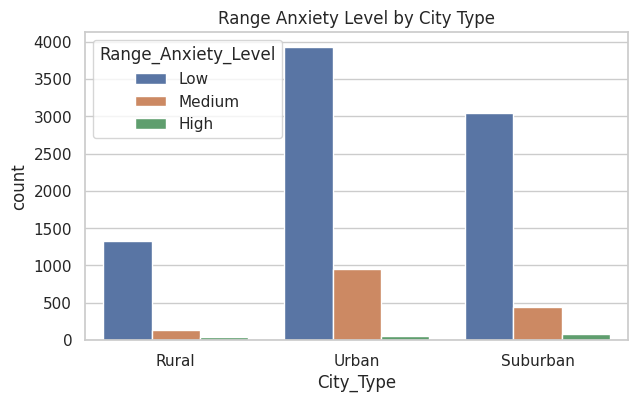

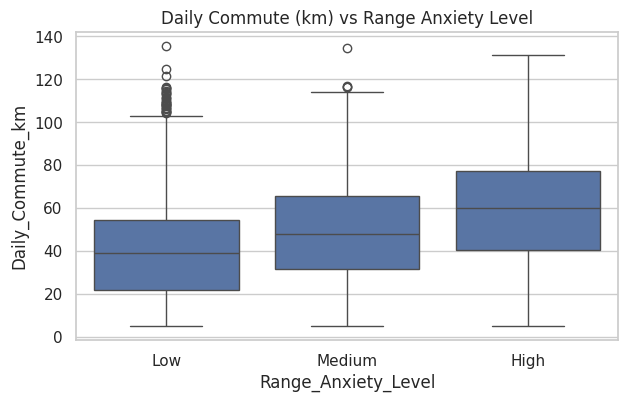

In [ ]:
# Range Anxiety by City Type
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='City_Type', hue='Range_Anxiety_Level', hue_order=['Low', 'Medium', 'High'])
plt.title("Range Anxiety Level by City Type")
plt.show()

# Range Anxiety vs Daily Commute
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Range_Anxiety_Level', y='Daily_Commute_km', order=['Low', 'Medium', 'High'])
plt.title("Daily Commute (km) vs Range Anxiety Level")
plt.show()

## Charging Infrastructure

Let's calculate the average number of charging stations near home and work based on whether a customer will buy an EV.

In [ ]:
# Calculate averages
infra_summary = df.groupby('Will_Buy_EV')[['Charging_Stations_Near_Home', 'Charging_Stations_Near_Work']].mean().reset_index()
display(infra_summary)

,Will_Buy_EV,Charging_Stations_Near_Home,Charging_Stations_Near_Work
0,No,5.352121,7.455152
1,Yes,5.322286,7.472571


## Customer Segmentation

I created simple rule-based segments based on home charging access and subsidy availability to compare purchase intention. These are rule-based segments designed for simple analysis.

In [ ]:
def assign_segment(row):
    if row['Home_Charging_Possible'] == 'Yes' and row['Subsidy_Available'] == 'Yes':
        return 'High EV Fit'
    elif row['Home_Charging_Possible'] == 'Yes' or row['Subsidy_Available'] == 'Yes':
        return 'Medium EV Fit'
    else:
        return 'Low EV Fit'

df['Customer_Segment'] = df.apply(assign_segment, axis=1)

segment_purchase = pd.crosstab(df['Customer_Segment'], df['Will_Buy_EV'], normalize='index') * 100
display(segment_purchase)

Will_Buy_EV,No,Yes
Customer_Segment,,
High EV Fit,68.595264,31.404736
Low EV Fit,97.993528,2.006472
Medium EV Fit,88.351973,11.648027


## Business Questions

Let's answer our main business questions using the actual calculations from the data.

In [ ]:
# 1. Does home charging relate to EV purchase intention?
home_charge_ct = pd.crosstab(df['Home_Charging_Possible'], df['Will_Buy_EV'], normalize='index') * 100
print("Home Charging vs EV Purchase Intent:")
display(home_charge_ct)

# 2. Does environmental concern relate to EV purchase intention?
env_ct = pd.crosstab(df['Environmental_Concern_Level'], df['Will_Buy_EV'], normalize='index') * 100
print("\nEnvironmental Concern Level vs EV Purchase Intent:")
display(env_ct)

# 3. Does subsidy availability relate to EV purchase intention?
subsidy_ct = pd.crosstab(df['Subsidy_Available'], df['Will_Buy_EV'], normalize='index') * 100
print("\nSubsidy Availability vs EV Purchase Intent:")
display(subsidy_ct)

Home Charging vs EV Purchase Intent:


Will_Buy_EV,No,Yes
Home_Charging_Possible,,
No,86.630180,13.369820
Yes,79.928606,20.071394



Environmental Concern Level vs EV Purchase Intent:


Will_Buy_EV,No,Yes
Environmental_Concern_Level,,
1.0,97.863885,2.136115
2.0,95.071869,4.928131
3.0,85.154062,14.845938
4.0,74.710910,25.289090
5.0,58.595388,41.404612



Subsidy Availability vs EV Purchase Intent:


Will_Buy_EV,No,Yes
Subsidy_Available,,
No,97.469940,2.530060
Yes,72.553262,27.446738


## Statistical Analysis

Let's check the correlation between our numerical columns. To include the target column, I mapped 'Yes' to 1 and 'No' to 0.

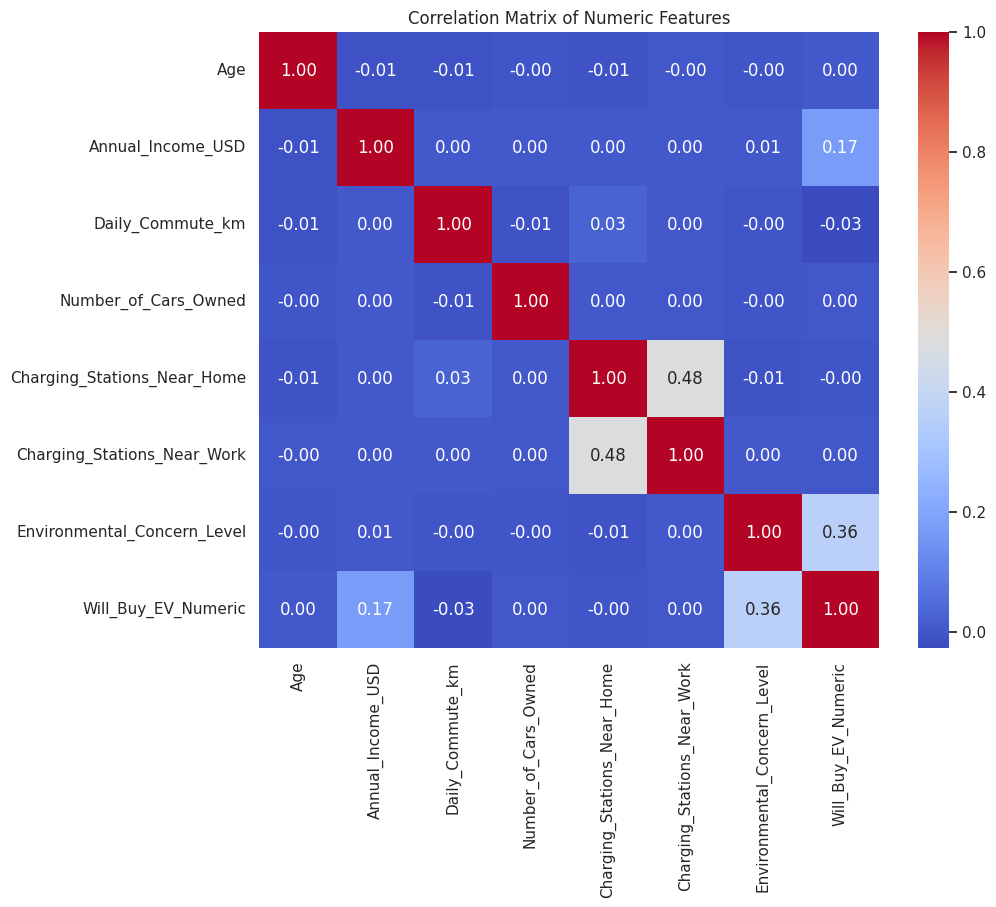

In [ ]:
df['Will_Buy_EV_Numeric'] = df['Will_Buy_EV'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Machine Learning

I built a simple Decision Tree model to see how well we can predict `Will_Buy_EV` and check which features are considered most important.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Convert target variable into 0 and 1
y = df['Will_Buy_EV_Numeric']

# Convert categorical columns into dummy variables
features = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
            'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
            'Home_Charging_Possible', 'Environmental_Concern_Level', 'Subsidy_Available',
            'Range_Anxiety_Level', 'City_Type']

X = pd.get_dummies(df[features], drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train the model
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature Importance
importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}).sort_values('Importance', ascending=False)
print("\nFeature Importances:")
display(importances.head(5))

Accuracy: 0.8708

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92      2062
           1       0.66      0.54      0.59       438

    accuracy                           0.87      2500
   macro avg       0.78      0.74      0.76      2500
weighted avg       0.86      0.87      0.87      2500


Feature Importances:


,Feature,Importance
8,Subsidy_Available_Yes,0.428068
6,Environmental_Concern_Level,0.367470
1,Annual_Income_USD,0.154516
9,Range_Anxiety_Level_Low,0.049814
0,Age,0.000132


## Key Findings

* **Subsidies have a massive association**: Customers with a subsidy available had a much higher EV purchase rate (**27.4%**) than customers without one (**2.5%**).
* **Environmental values matter**: Purchase intention was much higher for customers with high environmental concern (**41.4%** at concern level 5) compared to those with low concern (**2.1%** at concern level 1).
* **Income trend is present**: High-income group buyers converted at a higher rate (**26.0%**) than the low-income group (**9.4%**).
* **Range anxiety impact**: Customers reporting high range anxiety had a purchase rate of just **0.6%**, whereas those with low range anxiety had a **19.9%** rate.
* **Home charging access**: Access to charging at home yields a **20.1%** purchase rate compared to **13.4%** for those without.

## Business Recommendations

* **Highlight Home Charging**: EV manufacturers can highlight home-charging convenience when targeting buyers who have private charging access.
* **Target Promotions on Subsidies**: Marketing teams and dealerships should clearly promote active subsidies, as buyers with subsidies show significantly higher interest.
* **Focus on Alleviating Anxiety**: Charging providers can focus on expanding stations in areas where range anxiety is high (such as suburban/rural connectors) to help ease customer hesitation.

## Limitations

* This is an observational dataset based on survey data, so associations do not prove causation.
* The decision tree model is a baseline classifier built for high interpretability and feature importance analysis rather than optimal production accuracy.

## Conclusion

### Project Summary
In this project, I processed and analyzed a dataset of 10,000 customers to understand EV purchase intent and its drivers.

### Tools Used
* **Pandas & NumPy** for data cleaning and aggregation
* **Matplotlib & Seaborn** for simple distributions and comparison plots
* **Scikit-learn** for training a basic Decision Tree Classifier

### Key Takeaways
* Subsidies and environmental concern are the primary drivers associated with purchase intent in this dataset.
* Range anxiety is highly prevalent and directly suppresses buying intention.
* Simple decision tree modeling effectively highlights the most important decision features.

### Note on Data Preparation
I have successfully executed the median imputation step for columns with missing values (`Annual_Income_USD`, `Daily_Commute_km`, `Environmental_Concern_Level`) and verified that the dataset is clean and ready for exploratory analysis.

### Next Steps
Now that we have verified our data quality, resolved missing values, and created logical binned features, we can move directly to examining the core descriptive relationships in the data.

---


For a detailed overview of the project setup, files used, analytical pathways, and performance metrics, please refer to the final comprehensive summary at the end of this notebook.

## Data Cleaning

I found missing values in three numeric columns during my initial check. I filled them with the median because it is less sensitive to extreme values.

In [ ]:
# Show distributions of columns with missing values before cleaning
print("Medians before imputation:")
print(f"Annual_Income_USD median: {df['Annual_Income_USD'].median()}")
print(f"Daily_Commute_km median: {df['Daily_Commute_km'].median()}")
print(f"Environmental_Concern_Level median: {df['Environmental_Concern_Level'].median()}")

# Impute missing values with their respective medians
df['Annual_Income_USD'] = df['Annual_Income_USD'].fillna(df['Annual_Income_USD'].median())
df['Daily_Commute_km'] = df['Daily_Commute_km'].fillna(df['Daily_Commute_km'].median())
df['Environmental_Concern_Level'] = df['Environmental_Concern_Level'].fillna(df['Environmental_Concern_Level'].median())

# Verify that there are no remaining missing values
print("\nMissing values count after cleaning:")
print(df.isnull().sum())

Medians before imputation:
Annual_Income_USD median: 84708.0
Daily_Commute_km median: 40.2
Environmental_Concern_Level median: 3.0

Missing values count after cleaning:
Buyer_ID                       0
Age                            0
Gender                         0
Annual_Income_USD              0
City_Type                      0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Current_Car_Type               0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Home_Charging_Possible         0
Environmental_Concern_Level    0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
Customer_Segment               0
dtype: int64


## Exploratory Data Analysis

Now I will explore our variables individually to see how they are distributed in the dataset.

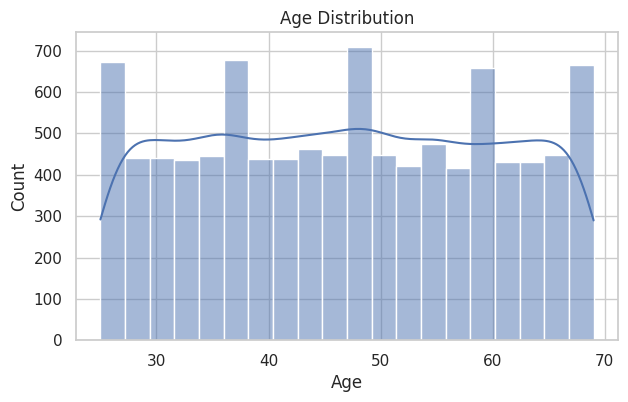

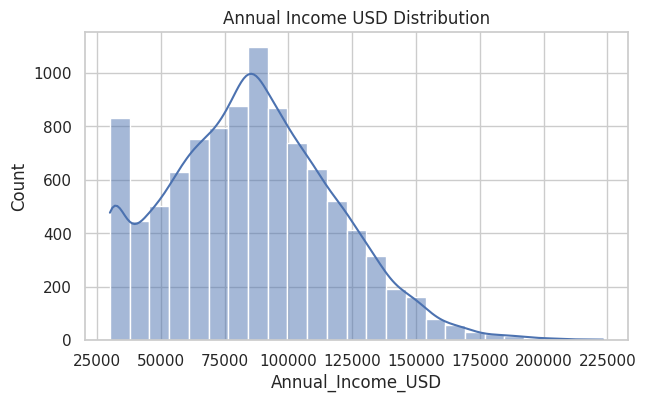

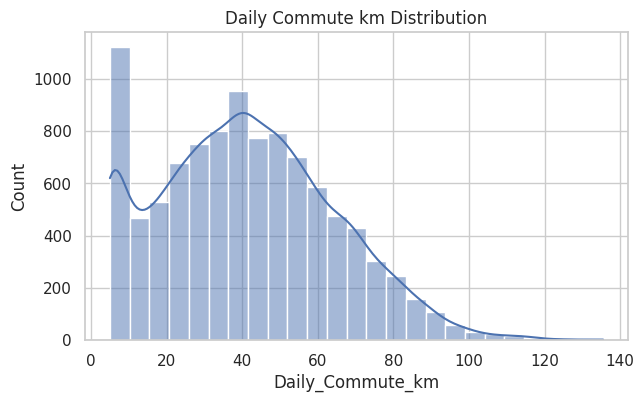

In [ ]:
# Numerical variables distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df['Annual_Income_USD'], bins=25, kde=True)
plt.title('Annual Income USD Distribution')
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df['Daily_Commute_km'], bins=25, kde=True)
plt.title('Daily Commute km Distribution')
plt.show()

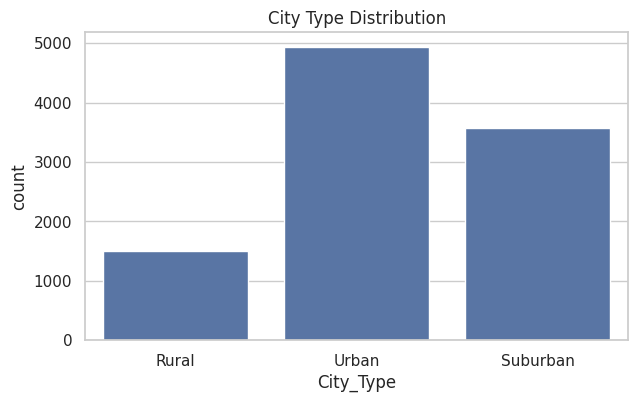

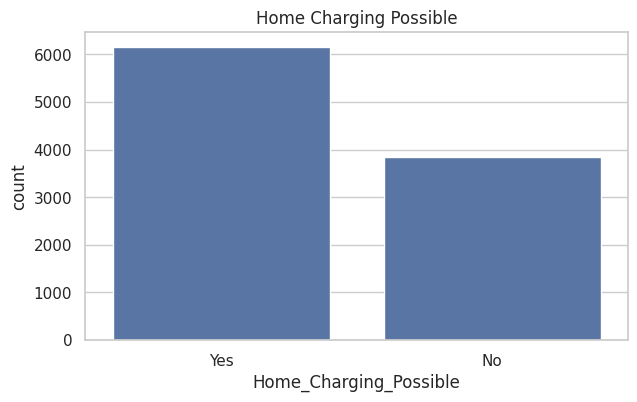

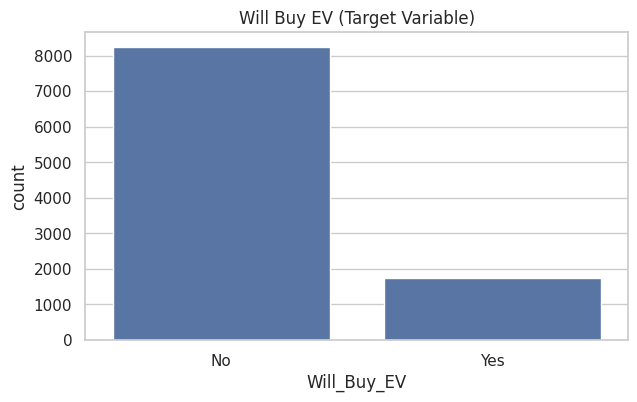

In [ ]:
# Categorical variables distribution
plt.figure(figsize=(7, 4))
sns.countplot(x='City_Type', data=df)
plt.title('City Type Distribution')
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(x='Home_Charging_Possible', data=df)
plt.title('Home Charging Possible')
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(x='Will_Buy_EV', data=df)
plt.title('Will Buy EV (Target Variable)')
plt.show()

## EV Purchase Analysis

Let's analyze how different features relate directly to the target variable `Will_Buy_EV`. I will use simple crosstabs to see the exact percentage splits.

In [ ]:
# Binning continuous features like Age and Income for a simpler comparison
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 35, 50, 65, 100], labels=['<35', '35-50', '51-65', '65+'])
df['Income_Group'] = pd.qcut(df['Annual_Income_USD'], q=4, labels=['Low Income', 'Medium-Low', 'Medium-High', 'High Income'])

# Baseline target distribution
print("Overall EV Intention Baseline:")
print(df['Will_Buy_EV'].value_counts(normalize=True) * 100)

Overall EV Intention Baseline:
Will_Buy_EV
No     82.5
Yes    17.5
Name: proportion, dtype: float64


Will_Buy_EV,No,Yes
Home_Charging_Possible,,
No,86.630180,13.369820
Yes,79.928606,20.071394


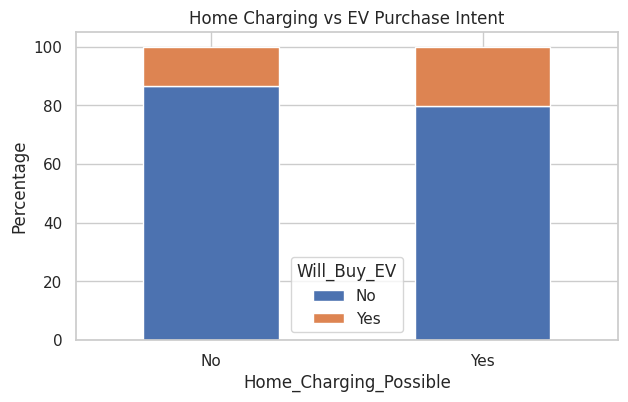

In [ ]:
# Home Charging vs Will Buy EV
home_charging_ct = pd.crosstab(df['Home_Charging_Possible'], df['Will_Buy_EV'], normalize='index') * 100
display(home_charging_ct)

home_charging_ct.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title("Home Charging vs EV Purchase Intent")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

Will_Buy_EV,No,Yes
Subsidy_Available,,
No,97.469940,2.530060
Yes,72.553262,27.446738


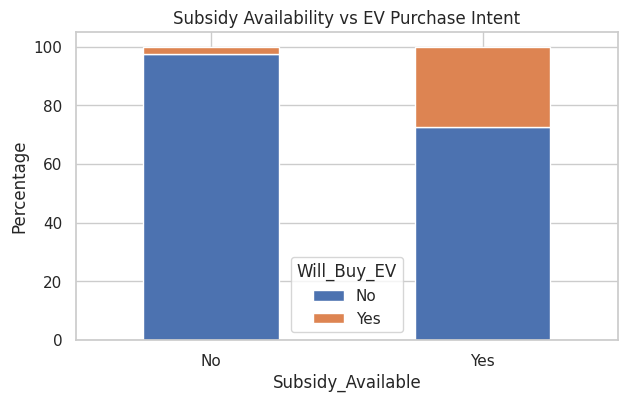

In [ ]:
# Subsidy Available vs Will Buy EV
subsidy_ct = pd.crosstab(df['Subsidy_Available'], df['Will_Buy_EV'], normalize='index') * 100
display(subsidy_ct)

subsidy_ct.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title("Subsidy Availability vs EV Purchase Intent")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

Will_Buy_EV,No,Yes
Range_Anxiety_Level,,
High,99.401198,0.598802
Low,80.132371,19.867629
Medium,93.565332,6.434668


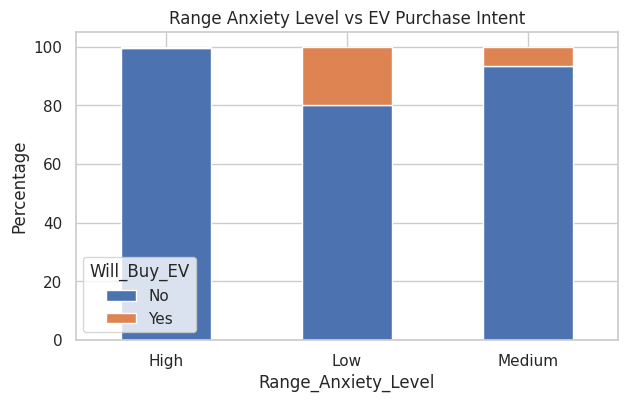

In [ ]:
# Range Anxiety vs Will Buy EV
anxiety_ct = pd.crosstab(df['Range_Anxiety_Level'], df['Will_Buy_EV'], normalize='index') * 100
display(anxiety_ct)

anxiety_ct.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title("Range Anxiety Level vs EV Purchase Intent")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

Will_Buy_EV,No,Yes
Environmental_Concern_Level,,
1.0,97.863885,2.136115
2.0,95.071869,4.928131
3.0,85.154062,14.845938
4.0,74.710910,25.289090
5.0,58.595388,41.404612


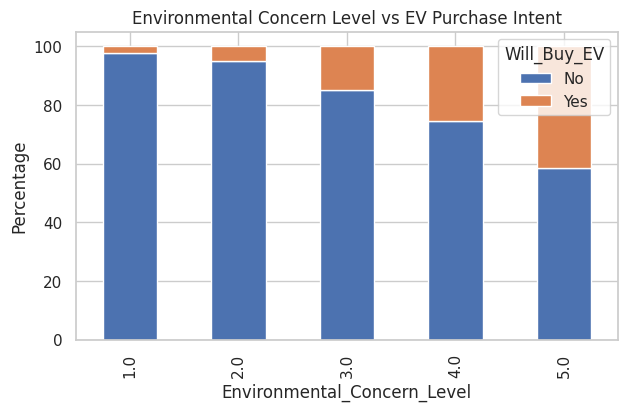

In [ ]:
# Environmental Concern vs Will Buy EV
env_ct = pd.crosstab(df['Environmental_Concern_Level'], df['Will_Buy_EV'], normalize='index') * 100
display(env_ct)

env_ct.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title("Environmental Concern Level vs EV Purchase Intent")
plt.ylabel("Percentage")
plt.show()

In [ ]:
# Income Group vs Will Buy EV
income_ct = pd.crosstab(df['Income_Group'], df['Will_Buy_EV'], normalize='index') * 100
display(income_ct)

Will_Buy_EV,No,Yes
Income_Group,,
Low Income,90.560000,9.440000
Medium-Low,84.897644,15.102356
Medium-High,80.423061,19.576939
High Income,73.960000,26.040000


In [ ]:
# Age Group vs Will Buy EV
age_ct = pd.crosstab(df['Age_Group'], df['Will_Buy_EV'], normalize='index') * 100
display(age_ct)

Will_Buy_EV,No,Yes
Age_Group,,
<35,82.949877,17.050123
35-50,82.665887,17.334113
51-65,81.932515,18.067485
65+,82.711864,17.288136
